# Unit 12 Artefact 2: Racing the Exploit. Does Patching at Human Speed Still Work?

Ian Stevens, Security and Risk Management, Unit 12.

The case I prepared for the Great Debate rests on one empirical claim: AI and automation are shortening the time between a vulnerability becoming known and its exploitation, so any defence that waits for a person to act falls further behind. This notebook tests that claim with the best public data I could find, and asks what it means for a business the size of Pampered Pets.

Sources and figures used:

* Charrier and Weiner (2024) analysed 138 vulnerabilities disclosed in 2023 and exploited in the wild: 97 (70%) were exploited as zero-days, before a patch or disclosure, and 41 (30%) as n-days. Of the n-days, 12% were exploited within one day of disclosure, 29% within a week, 56% within a month and all but two (95%) within six months. The average time-to-exploit (TTE) was 63 days in 2018-19, 44 days in 2020-21, 32 days in 2021-22 and 5 days in 2023.
* Kutscher (2026), introducing M-Trends 2026, reports that the mean TTE 'dropped to an estimated -7 days' in 2025.
* Verizon (2025) found that only about 54% of edge device and VPN vulnerabilities were fully remediated during the year, at a median of 32 days.

Three questions: (1) what does the headline TTE actually measure; (2) which patching policies keep pace for a small business, now and if exploitation becomes two, four or eight times faster; (3) how much of the exposure can patching reach at all?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK, RED = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e", "#c23b3b"
rng = np.random.default_rng(2026)

# Charrier and Weiner (2024): timing of the 41 n-days disclosed in 2023 (cumulative counts)
days = np.array([1, 7, 30, 180])
share = np.array([5, 12, 23, 39]) / 41
ZERO_DAY_SHARE_2023 = 97 / 138
print(pd.DataFrame({"within (days)": days, "n-days": [5, 12, 23, 39], "cumulative share": share.round(3)}).to_string(index=False))
print(f"zero-day share 2023: {ZERO_DAY_SHARE_2023:.1%}")

 within (days)  n-days  cumulative share
             1       5             0.122
             7      12             0.293
            30      23             0.561
           180      39             0.951
zero-day share 2023: 70.3%

## 1. The n-day timing curve

Four points are too few to pin down a distribution. A lognormal fitted to them by least squares misses badly at both ends, so I use the empirical curve instead: the four published points, joined by straight lines, with the curve starting at 0 on day 0 and reaching 100% at 365 days. The last point is my assumption, since the article says only that two n-days were exploited after six months. Within each interval exploitation is spread evenly.

In [2]:
def ln_cdf(p, x):
    return lognorm(s=p[1], scale=np.exp(p[0])).cdf(x)
fit = minimize(lambda p: np.sum((ln_cdf(p, days) - share) ** 2), [np.log(20), 1.5], method="Nelder-Mead").x
print("lognormal fit vs data:", np.round(ln_cdf(fit, days), 3), "vs", np.round(share, 3))

knots_t = np.array([0, 1, 7, 30, 180, 365.0])
knots_p = np.r_[0, share, 1.0]
def nday_cdf(t):
    return np.interp(t, knots_t, knots_p)
def sample_tte(n):
    return np.interp(rng.uniform(0, 1, n), knots_p, knots_t)

nday_mean = np.sum(np.diff(knots_p) * (knots_t[:-1] + knots_t[1:]) / 2)
print(f"empirical n-day curve: median {np.interp(0.5, knots_p, knots_t):.1f} days, mean {nday_mean:.1f} days")

lognormal fit vs data: [0.059 0.301 0.603 0.889] vs [0.122 0.293 0.561 0.951]
empirical n-day curve: median 24.8 days, mean 60.0 days

## 2. What the headline average measures

The headline TTE is an average over two different populations. A zero-day is exploited before it is disclosed, so its TTE is zero or negative; an n-day is exploited afterwards. If the 2023 average of 5 days was taken over all 138 vulnerabilities, and the n-days averaged about 60 days as the curve above implies, the zero-days must have averaged roughly 18 days *before* disclosure. That is an inference from the published figures, not a number Mandiant reports.

The more important point is what moves the average. The chart on the right holds the n-day curve fixed at its 2023 shape and varies only the share of zero-days and how long before disclosure they are exploited. The average passes from +5 to -7 days without any n-day being exploited a day sooner. A negative mean in 2025 therefore tells us that zero-days became a larger share, or were found earlier, or both; on its own it does not show that attackers turned published patches into exploits faster.

implied mean TTE of 2023 zero-days: -18.2 days
zero-day share         70%   80%   90%
zero-day mean (days)                  
-30                   -3.0 -12.0 -21.0
-18                    5.4  -2.4 -10.2
-10                   11.0   4.0  -3.0

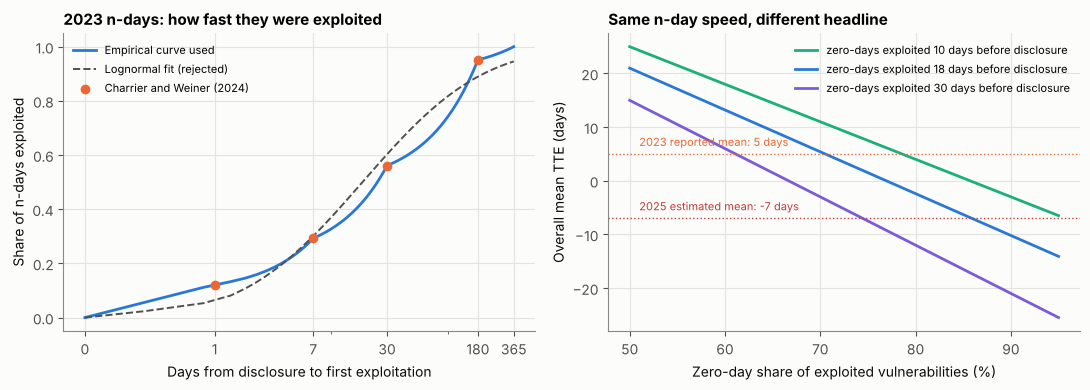

In [3]:
implied_zero_mean = (5 - (1 - ZERO_DAY_SHARE_2023) * nday_mean) / ZERO_DAY_SHARE_2023
print(f"implied mean TTE of 2023 zero-days: {implied_zero_mean:.1f} days")

def overall_mean(z_share, z_mean):
    return z_share * z_mean + (1 - z_share) * nday_mean

shares = np.linspace(0.5, 0.95, 100)
rows = []
for z in (-10, -18, -30):
    for s in (0.70, 0.80, 0.90):
        rows.append({"zero-day mean (days)": z, "zero-day share": f"{s:.0%}", "overall mean TTE": round(overall_mean(s, z), 1)})
print(pd.DataFrame(rows).pivot(index="zero-day mean (days)", columns="zero-day share", values="overall mean TTE").to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
t = np.linspace(0, 365, 800)
ax[0].plot(t, nday_cdf(t), color=BLUE, label="Empirical curve used")
ax[0].plot(t, ln_cdf(fit, t), color=INK, ls="--", lw=1.4, label="Lognormal fit (rejected)")
ax[0].scatter(days, share, color=ORANGE, zorder=3, label="Charrier and Weiner (2024)")
ax[0].set_xscale("symlog", linthresh=1); ax[0].set_xticks([0, 1, 7, 30, 180, 365], ["0", "1", "7", "30", "180", "365"])
ax[0].set_xlabel("Days from disclosure to first exploitation"); ax[0].set_ylabel("Share of n-days exploited")
ax[0].set_title("2023 n-days: how fast they were exploited", loc="left"); ax[0].legend(frameon=False, fontsize=8)
for z, c in ((-10, AQUA), (-18, BLUE), (-30, VIOLET)):
    ax[1].plot(shares * 100, overall_mean(shares, z), color=c, label=f"zero-days exploited {-z} days before disclosure")
ax[1].axhline(5, color=ORANGE, lw=1, ls=":"); ax[1].text(51, 6.5, "2023 reported mean: 5 days", color=ORANGE, fontsize=8)
ax[1].axhline(-7, color=RED, lw=1, ls=":"); ax[1].text(51, -5.5, "2025 estimated mean: -7 days", color=RED, fontsize=8)
ax[1].set_xlabel("Zero-day share of exploited vulnerabilities (%)"); ax[1].set_ylabel("Overall mean TTE (days)")
ax[1].set_title("Same n-day speed, different headline", loc="left"); ax[1].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig("figures/u12_tte.png", dpi=150, bbox_inches="tight")

## 3. The patching race at a small business

For an n-day the question is whether the fix is installed before the vulnerability is first exploited. I compare four policies, each described by the delay between a patch being released and it being installed:

| Policy | Delay model | Basis |
|---|---|---|
| Manual, when someone gets round to it | lognormal, median 32 days | Verizon's (2025) median for edge devices, which are patched by professionals; a four-person shop may be slower |
| Cyber Essentials rule | uniform, 0 to 14 days | High and critical updates within 14 days of release (NCSC, 2026) |
| Automatic updates | uniform, 0 to 2 days | Updates installed by the device or application itself |
| Supplier-managed service (SaaS) | uniform, 0 to 1 day | The provider patches its own service; the customer does nothing |

Exploitation speed is then compressed by a factor of 2, 4 and 8, which is a scenario rather than a forecast: it asks what happens if AI tools let attackers move from patch to exploit several times faster. The chance that an n-day is exploited before the patch is installed is P(TTE / compression < delay), with the two treated as independent.

P(an n-day is exploited before the patch is installed)
                                    x1     x2     x4     x8
Manual (median 32 days)          54.8%  67.6%  80.1%  90.1%
Cyber Essentials (0-14 days)     26.2%  36.0%  47.6%  58.9%
Automatic updates (0-2 days)     10.0%  14.0%  20.2%  27.7%
Supplier-managed SaaS (0-1 day)   6.2%   9.9%  14.0%  20.2%

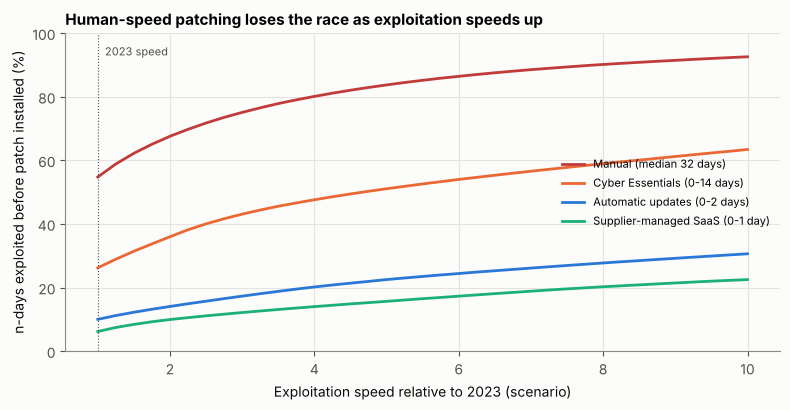

In [4]:
N = 400_000
tte = sample_tte(N)
policies = {
    "Manual (median 32 days)": lognorm(s=1.0, scale=32).rvs(N, random_state=rng),
    "Cyber Essentials (0-14 days)": rng.uniform(0, 14, N),
    "Automatic updates (0-2 days)": rng.uniform(0, 2, N),
    "Supplier-managed SaaS (0-1 day)": rng.uniform(0, 1, N),
}
comp = [1, 2, 4, 8]
race = pd.DataFrame({f"x{c}": {k: np.mean(tte / c < v) for k, v in policies.items()} for c in comp})
print("P(an n-day is exploited before the patch is installed)")
print((race * 100).round(1).astype(str).add("%").to_string())

cs = np.linspace(1, 10, 37)
fig, ax = plt.subplots(figsize=(8, 4.2))
for (k, v), col in zip(policies.items(), (RED, ORANGE, BLUE, AQUA)):
    ax.plot(cs, [np.mean(tte / c < v) * 100 for c in cs], color=col, label=k)
ax.axvline(1, color=INK, lw=0.8, ls=":"); ax.text(1.1, 93, "2023 speed", fontsize=8, color=INK)
ax.set_xlabel("Exploitation speed relative to 2023 (scenario)"); ax.set_ylabel("n-days exploited before patch installed (%)")
ax.set_ylim(0, 100); ax.set_title("Human-speed patching loses the race as exploitation speeds up", loc="left")
ax.legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()
fig.savefig("figures/u12_race.png", dpi=150, bbox_inches="tight")

## 4. How much of the exposure can patching reach?

Patching cannot help with a zero-day, because no fix exists when exploitation starts. Using the 2023 mix, the chart splits every 100 exploited vulnerabilities into those exploited before any fix existed, those exploited while the fix waited to be installed, and those patched in time.

Fastest uniform patch window (0 to D days) that keeps n-days exploited first at or below 10%:
  exploitation x1: D = 1.9 days
  exploitation x2: D = 1.0 days
  exploitation x4: D = 0.5 days
  exploitation x8: D = 0.2 days

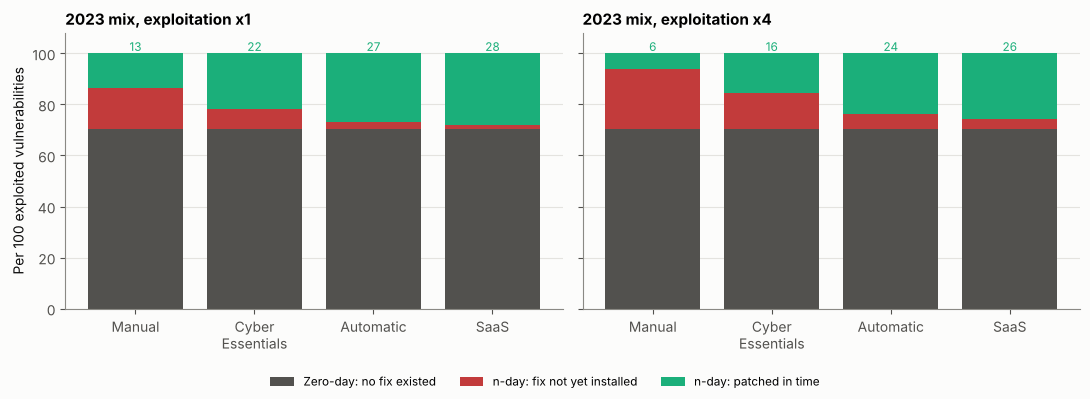

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
labels = ["Manual", "Cyber\nEssentials", "Automatic", "SaaS"]
for a, c in zip(ax, (1, 4)):
    p = race[f"x{c}"].values
    zd = np.full(4, ZERO_DAY_SHARE_2023 * 100)
    late = (1 - ZERO_DAY_SHARE_2023) * p * 100
    ok = (1 - ZERO_DAY_SHARE_2023) * (1 - p) * 100
    a.bar(labels, zd, color=INK, label="Zero-day: no fix existed")
    a.bar(labels, late, bottom=zd, color=RED, label="n-day: fix not yet installed")
    a.bar(labels, ok, bottom=zd + late, color=AQUA, label="n-day: patched in time")
    for i in range(4):
        a.text(i, 101, f"{ok[i]:.0f}", ha="center", fontsize=8.5, color=AQUA)
    a.set_title(f"2023 mix, exploitation x{c}", loc="left"); a.set_ylim(0, 108)
    a.set_axisbelow(True); a.grid(axis="x", visible=False)
ax[0].set_ylabel("Per 100 exploited vulnerabilities")
h, l = ax[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.legend(h, l, frameon=False, fontsize=8.5, loc="lower center", ncol=3)
fig.savefig("figures/u12_exposure.png", dpi=150, bbox_inches="tight")

print("Fastest uniform patch window (0 to D days) that keeps n-days exploited first at or below 10%:")
grid = np.linspace(0.05, 30, 600)
for c in comp:
    ok = [D for D in grid if np.mean(tte[:100_000] / c < rng.uniform(0, D, 100_000)) <= 0.10]
    print(f"  exploitation x{c}: D = {max(ok):.1f} days" if ok else f"  exploitation x{c}: below 0.05 days")

## 5. What this means for the debate

* **The trend is real, but the headline number overstates what we know about it.** The fall from 63 days to 5 is large, and the 2025 estimate is negative. Section 2 shows that a mean taken over zero-days and n-days together moves with the mix as much as with speed. This is the measurement problem Nicol et al. (2012) put among their five hard problems: a security metric should be repeatable and validated, and a single average over two populations is neither. I would ask for the n-day curve and the zero-day share to be reported separately.
* **Even at 2023 speed, a person patching when they can loses the race for most n-days.** With a median delay of 32 days, about 55% of n-days are exploited before the fix is installed. The Cyber Essentials 14-day rule brings this to about 26%, automatic updates to about 10% and a supplier-managed service to about 6%. If exploitation became four times faster, the manual policy would lose four races in five and the 14-day rule about half, and only automatic or supplier-managed patching would stay at or below one in five. Keeping the loss to one n-day in ten needs every patch installed within about two days at 2023 speed, and within half a day at four times that speed. That is not a task for a person.
* **Patching reaches at most 30% of the problem.** Seven in ten exploited vulnerabilities in 2023 were zero-days. For those, the defences that count are the ones Nicol et al. group under resilient architectures: limiting what a compromised component can reach, detecting it, and restoring from a copy it cannot touch, as recommended for Pampered Pets in Unit 10.
* **For Pampered Pets the practical answer is to let the supplier be the automation.** Rented services patched by the provider, automatic updates switched on for every device, and the old warehouse PC replaced or isolated. This is the same conclusion as Unit 11, reached from a different direction: AI's influence on a small firm arrives through the speed it forces on its suppliers.

**Limitations.** The n-day curve rests on 41 vulnerabilities tracked by one vendor, mostly in enterprise products, and 'first exploitation in the wild' is not the same as exploitation of a particular small business, which usually comes later through mass scanning. The 365-day end point and the policy delay models are my assumptions. Treating exploitation and patching as independent ignores that the most publicised vulnerabilities are patched and exploited fastest. The compression factors are scenarios, not forecasts.